# DINOv3 ViT-L/16 — AttnLRP attribution (working recipe)

Demonstrates the composite that produces well-conditioned heatmaps on
DINOv3 ViT-L/16 with a 1024 → 1000 linear probe trained on Imagenette.

**Recipe:**

```python
AttnLRPCombinedComposite(
    matmul_factor_2=True,        # AttnLRP Prop 3.3 bilinear rule
    layerscale_uniform=True,     # AttnLRP Eq. 7 uniform on LayerScale γ
    residual_lrp='ratio',        # Otsuki ratio split on residual additions
)
```

See [`FINDINGS.md`](FINDINGS.md) in this folder for the full per-rule
explanation. TL;DR — the three ingredients address three distinct gaps
in bare ε-LRP for transformers; each on its own is insufficient, the
combination is the AttnLRP-correct baseline for LayerScale-bearing
ViTs.

## 1. Setup — load DINOv3 + probe head

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').is_file():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))

import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from timm.data import resolve_data_config, create_transform

from crp.attribution import CondAttribution
from crp.transformer_patches import (
    AttnLRPCombinedComposite,
    AttnLRPEpsilonComposite,
)
from datasets import load as load_dataset
from dinov3_diagnose import diagnose_attribution, format_report

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PROBE_PATH = REPO_ROOT / 'data/vit_large_patch16_dinov3_probe_imagenette.pt'
print(f'device: {DEVICE}')
print(f'probe : {PROBE_PATH}')

device: cuda
probe : /home/claude/workspaces/zennit-crp/data/vit_large_patch16_dinov3_probe_imagenette.pt


In [2]:
ckpt = torch.load(PROBE_PATH, map_location=DEVICE, weights_only=False)
model = timm.create_model(
    ckpt['model_name'], pretrained=True, num_classes=ckpt['num_classes'],
).eval().to(DEVICE)
model.head.load_state_dict(ckpt['head_state_dict'])
for p in model.parameters():
    p.requires_grad_(False)

cfg = resolve_data_config({}, model=model)
transform = create_transform(**cfg, is_training=False)
print(f'model       : {ckpt["model_name"]}')
print(f'embed_dim   : {model.embed_dim}')
print(f'blocks      : {len(model.blocks)}')
print(f'num_prefix  : {model.num_prefix_tokens} (1 cls + 4 register)')

model       : vit_large_patch16_dinov3
embed_dim   : 1024
blocks      : 24
num_prefix  : 5 (1 cls + 4 register)


## 2. Pick 3 correctly-classified, class-distinct images

In [3]:
dataset = load_dataset('imagenette', split='val', transform=transform)
samples = []
seen = set()
stride = max(1, len(dataset) // 30)
for i in range(0, len(dataset), stride):
    x, y = dataset[i]
    if int(y) in seen:
        continue
    x_dev = x.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(x_dev).argmax(-1).item()
    if pred == int(y):
        samples.append((x_dev.detach().requires_grad_(True), pred))
        seen.add(int(y))
    if len(samples) == 3:
        break
print(f'picked {len(samples)} samples, classes: {[s[1] for s in samples]}')

  exists: /home/claude/workspaces/zennit-crp/data/imagenette2-160.tgz
  extracted: /home/claude/workspaces/zennit-crp/data/imagenette2-160


picked 3 samples, classes: [0, 217, 482]


## 3. Diagnostic — confirm magnitudes are sane

The diagnostic records relevance health at every
`blocks.{i}.attn.attn_out_tap`. Expect `finite_share = 1.0`
everywhere and `max|R|` to stay well below fp32 max (~3.4e+38).

In [4]:
composite = AttnLRPCombinedComposite(
    matmul_factor_2=True,
    layerscale_uniform=True,
    residual_lrp='ratio',
)
attribution = CondAttribution(model)

x0, cls0 = samples[0]
report = diagnose_attribution(
    model, attribution, composite, x0.clone().requires_grad_(True),
    target_class=cls0, composite_label='working_combo',
    num_prefix_tokens=model.num_prefix_tokens,
)
print(format_report(report, max_layers_to_show=12))

=== working_combo  •  cls 0 ===
  heatmap: finite=True  max_abs=2.319e+02  focus_top10%=0.832  register_leak=0.000
  per-layer relevance (24 taps):
    [ 0] blocks.0.attn.attn_out_tap                          max_abs=4.36e+01  mean_abs=3.95e-03  nan=   0
    [ 2] blocks.2.attn.attn_out_tap                          max_abs=2.52e+00  mean_abs=1.09e-03  nan=   0
    [ 4] blocks.4.attn.attn_out_tap                          max_abs=2.20e+02  mean_abs=8.57e-03  nan=   0
    [ 6] blocks.6.attn.attn_out_tap                          max_abs=5.56e+01  mean_abs=7.20e-03  nan=   0
    [ 8] blocks.8.attn.attn_out_tap                          max_abs=1.30e+01  mean_abs=9.33e-03  nan=   0
    [10] blocks.10.attn.attn_out_tap                         max_abs=4.55e+01  mean_abs=1.46e-02  nan=   0
    [12] blocks.12.attn.attn_out_tap                         max_abs=1.46e+01  mean_abs=2.11e-02  nan=   0
    [14] blocks.14.attn.attn_out_tap                         max_abs=3.18e+01  mean_abs=4.61e-02  nan= 

/home/claude/workspaces/zennit-crp/.venv/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## 4. Spatial heatmaps — three classes

Each row: input image | raw heatmap (channel-summed, signed) |
per-image absolute-normalised heatmap. Prefix tokens (cls + 4
register) are dropped from the spatial layout per Darcet et al.
(arXiv:2309.16588) — they don't correspond to image patches.

In [5]:
def heatmap_2d(result):
    hm = result.heatmap[0]
    if hm.dim() == 3 and hm.shape[0] == 3:
        hm = hm.sum(dim=0)
    return hm.detach().cpu().numpy()

def denormalise(x):
    mean = torch.tensor(cfg['mean'], device=x.device).view(3, 1, 1)
    std  = torch.tensor(cfg['std'], device=x.device).view(3, 1, 1)
    return (x.squeeze(0).detach() * std + mean).clamp(0, 1).cpu().permute(1, 2, 0).numpy()

results = []
for x, cls in samples:
    x_run = x.clone().requires_grad_(True)
    res = attribution(x_run, [{'y': [cls]}], composite)
    results.append((x, cls, res))

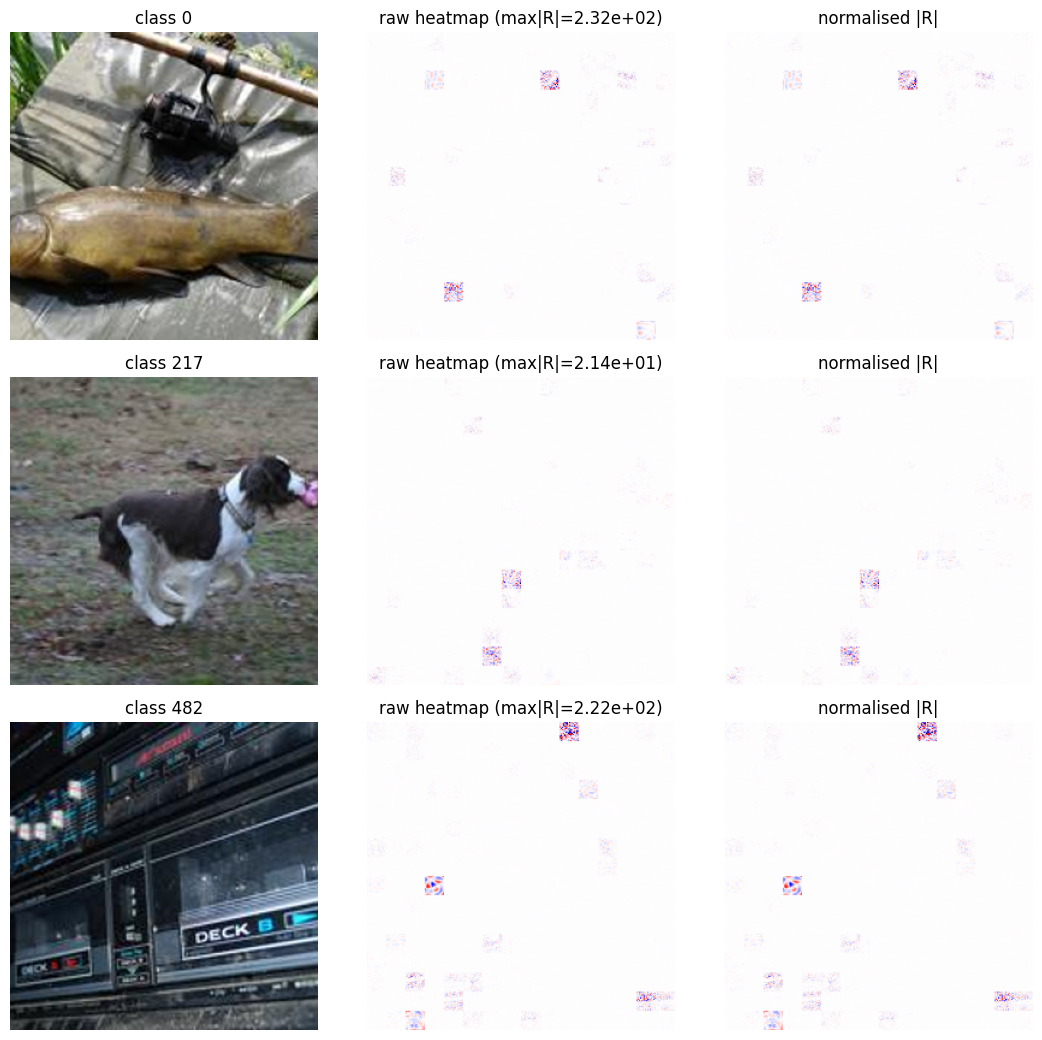

In [6]:
fig, axes = plt.subplots(len(results), 3, figsize=(11, 3.5 * len(results)))
for i, (x, cls, res) in enumerate(results):
    img = denormalise(x)
    hm = heatmap_2d(res)
    finite = np.isfinite(hm).all()
    vmax = np.abs(hm).max() if finite else float('nan')

    ax_im, ax_raw, ax_norm = axes[i]
    ax_im.imshow(img); ax_im.set_title(f'class {cls}'); ax_im.axis('off')

    if finite:
        ax_raw.imshow(hm, cmap='seismic', vmin=-vmax, vmax=vmax)
        ax_raw.set_title(f'raw heatmap (max|R|={vmax:.2e})')
        # Per-image normalised: same colourmap, scaled to peak = ±1.
        ax_norm.imshow(hm / (vmax + 1e-30), cmap='seismic', vmin=-1, vmax=1)
        ax_norm.set_title('normalised |R|')
    else:
        ax_raw.text(0.5, 0.5, 'NaN', ha='center', va='center', fontsize=20, color='red')
        ax_raw.set_title('raw heatmap (NON-finite)')
        ax_norm.set_title('—')
    ax_raw.axis('off')
    ax_norm.axis('off')

plt.tight_layout()
plt.show()

## 5. Side-by-side with the broken baseline

`AttnLRPEpsilonComposite()` (no matmul rule, no residual rule) NaN's
on DINOv3 — the conservation gap accumulates past fp32 max. Cell
below confirms the contrast.

In [7]:
baseline = AttnLRPEpsilonComposite()
x_run = samples[0][0].clone().requires_grad_(True)
res = attribution(x_run, [{'y': [samples[0][1]]}], baseline)
hm = heatmap_2d(res)
print(f'baseline ε-LRP: finite share = {np.isfinite(hm).mean():.3f}')
print(f'baseline ε-LRP: max|R|       = {np.abs(hm).max() if np.isfinite(hm).all() else "NaN"}')

baseline ε-LRP: finite share = 0.000
baseline ε-LRP: max|R|       = NaN


## 6. Register-token inspection

DINOv3 uses 5 prefix tokens (1 cls + 4 register). Per Darcet et al.
ICLR 2024 (arXiv:2309.16588), register tokens absorb high-norm
artifacts and don't correspond to spatial patches. The diagnostic's
`register_leak_share` reports the fraction of total |R| living on
those tokens at the deepest recorded tap. With DINOv3's avg-pool
head, that's structurally 0 — relevance only enters via patch tokens.

For block-internal inspection, the per-token relevance can be looked
up at any `attn_out_tap`. The cell below dumps the cls + register
token absolute-relevance at one mid-stack layer — useful for the
register-attention investigation but kept separate from the spatial
heatmap above.

In [8]:
x_run = samples[0][0].clone().requires_grad_(True)
MID_LAYER = f'blocks.{len(model.blocks) // 2}.attn.attn_out_tap'
res = attribution(x_run, [{'y': [samples[0][1]]}], composite,
                  record_layer=[MID_LAYER])
rel = res.relevances[MID_LAYER]   # (B, N, D)
if rel.dim() == 4:  # (1, B, N, D) some pipelines
    rel = rel[0]
if rel.dim() == 3 and rel.shape[0] == 1:
    rel = rel[0]   # drop batch -> (N, D)
npt = model.num_prefix_tokens
if rel.dim() == 2 and rel.shape[0] > npt:
    print(f'{MID_LAYER} per-token |R| (top {npt} = cls + register):')
    for t in range(npt):
        kind = 'cls' if t == 0 else f'reg{t-1}'
        print(f'  token {t} ({kind}): |R|.sum() = {rel[t].abs().sum().item():.3e}')
    patch_total = rel[npt:].abs().sum().item()
    print(f'  patch tokens (sum) = {patch_total:.3e}')
else:
    print(f'unexpected shape {tuple(rel.shape)}')

blocks.12.attn.attn_out_tap per-token |R| (top 5 = cls + register):
  token 0 (cls): |R|.sum() = 1.594e+01
  token 1 (reg0): |R|.sum() = 4.505e+00
  token 2 (reg1): |R|.sum() = 4.387e+00
  token 3 (reg2): |R|.sum() = 9.599e+00
  token 4 (reg3): |R|.sum() = 7.261e+00
  patch tokens (sum) = 5.603e+03
